<a href="https://colab.research.google.com/github/Salimam00/pinn-thermoelasticity-rods/blob/main/prediction_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/Salimam00/pinn-thermoelasticity-rods/main/prediction_data.csv"

df = pd.read_csv(url)

print("Количество точек:", len(df))
print("Количество столбцов:", len(df.columns))

display(df.head())

Количество точек: 400
Количество столбцов: 8


,x_m,area_m2,temperature_change_K,u_analytical_m,u_deep_ritz_m,absolute_error_m,stress_analytical_Pa,stress_deep_ritz_Pa
0,0.000000,0.001,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+07,1.014148e+07
1,0.002506,0.001,0.250627,1.290829e-07,1.307989e-07,1.716001e-09,1.000019e+07,1.013262e+07
2,0.005013,0.001,0.501253,2.657081e-07,2.690280e-07,3.319899e-09,1.000075e+07,1.012434e+07
3,0.007519,0.001,0.751880,4.098805e-07,4.146949e-07,4.814410e-09,1.000170e+07,1.011667e+07
4,0.010025,0.001,1.002506,5.616046e-07,5.678069e-07,6.202241e-09,1.000302e+07,1.010958e+07


In [3]:
import os

os.makedirs("results", exist_ok=True)

print("Папка results готова.")

Папка results готова.


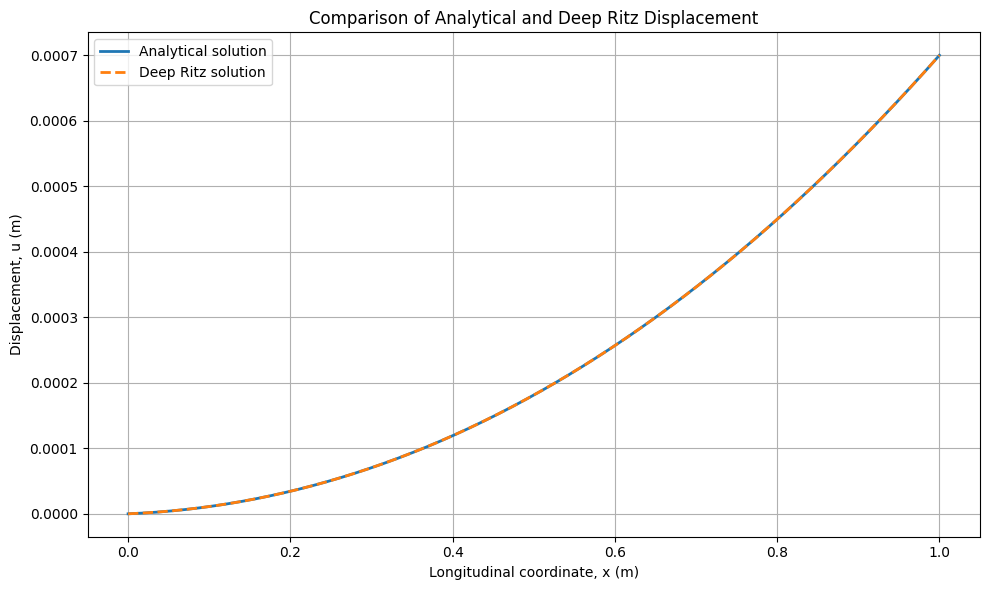

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["u_analytical_m"],
    label="Analytical solution",
    linewidth=2
)

plt.plot(
    df["x_m"],
    df["u_deep_ritz_m"],
    "--",
    label="Deep Ritz solution",
    linewidth=2
)

plt.xlabel("Longitudinal coordinate, x (m)")
plt.ylabel("Displacement, u (m)")
plt.title("Comparison of Analytical and Deep Ritz Displacement")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/Figure_4_displacement_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

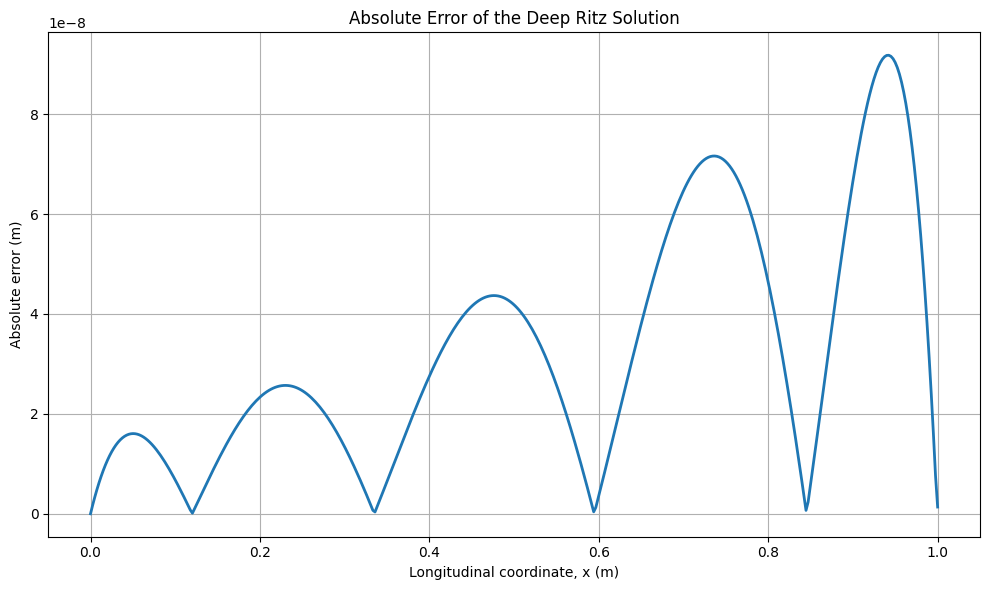

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["absolute_error_m"],
    linewidth=2
)

plt.xlabel("Longitudinal coordinate, x (m)")
plt.ylabel("Absolute error (m)")
plt.title("Absolute Error of the Deep Ritz Solution")
plt.grid(True)
plt.tight_layout()

plt.savefig("results/Figure_5_absolute_error.png", dpi=300)
plt.show()

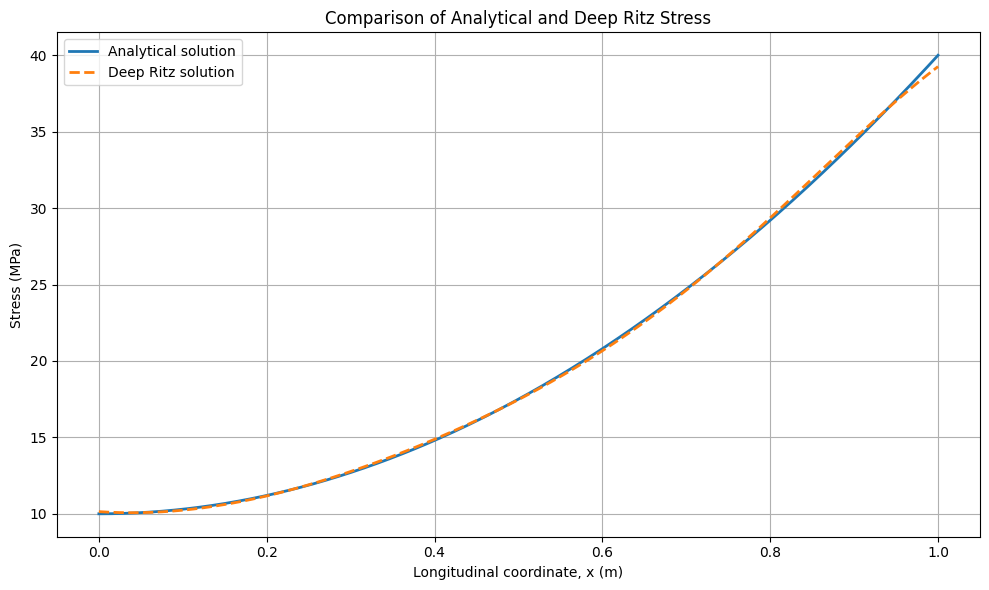

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["stress_analytical_Pa"] / 1e6,
    label="Analytical solution",
    linewidth=2
)

plt.plot(
    df["x_m"],
    df["stress_deep_ritz_Pa"] / 1e6,
    "--",
    label="Deep Ritz solution",
    linewidth=2
)

plt.xlabel("Longitudinal coordinate, x (m)")
plt.ylabel("Stress (MPa)")
plt.title("Comparison of Analytical and Deep Ritz Stress")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("results/Figure_6_stress_comparison.png", dpi=300)
plt.show()

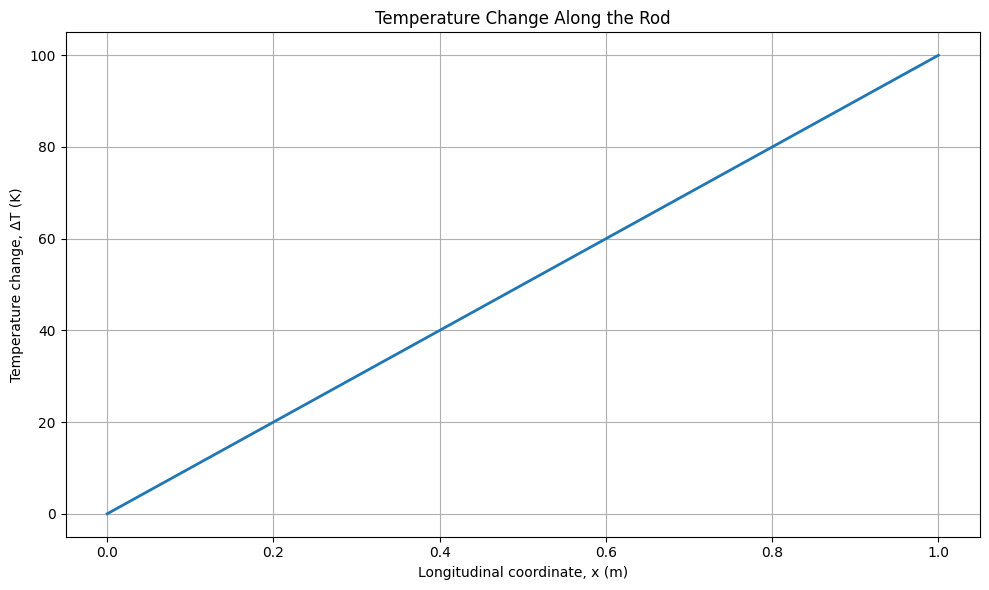

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["temperature_change_K"],
    linewidth=2
)

plt.xlabel("Longitudinal coordinate, x (m)")
plt.ylabel("Temperature change, ΔT (K)")
plt.title("Temperature Change Along the Rod")
plt.grid(True)
plt.tight_layout()

plt.savefig("results/Figure_7_temperature_distribution.png", dpi=300)
plt.show()

In [9]:
# ============================================================
# NUMERICAL RESULTS
# ============================================================

max_error = df["absolute_error_m"].max()
mean_error = df["absolute_error_m"].mean()

rmse = np.sqrt(
    np.mean(
        (df["u_analytical_m"] - df["u_deep_ritz_m"]) ** 2
    )
)

max_u_analytical = df["u_analytical_m"].abs().max()
max_u_deep_ritz = df["u_deep_ritz_m"].abs().max()

max_stress_analytical = df["stress_analytical_Pa"].abs().max()
max_stress_deep_ritz = df["stress_deep_ritz_Pa"].abs().max()

# Relative error, excluding x = 0
relative_error = (
    df["absolute_error_m"] /
    df["u_analytical_m"].replace(0, np.nan)
)

max_relative_error = relative_error.max() * 100
mean_relative_error = relative_error.mean() * 100

max_error_index = df["absolute_error_m"].idxmax()

print("=" * 60)
print("NUMERICAL RESULTS")
print("=" * 60)

print(f"Number of points: {len(df)}")

print("\nDISPLACEMENT ERROR")
print(f"Maximum absolute error : {max_error:.6e} m")
print(f"Mean absolute error    : {mean_error:.6e} m")
print(f"RMSE                   : {rmse:.6e} m")

print(f"Maximum relative error : {max_relative_error:.6f} %")
print(f"Mean relative error    : {mean_relative_error:.6f} %")

print("\nDISPLACEMENT")
print(
    f"Maximum analytical displacement : "
    f"{max_u_analytical:.6e} m"
)

print(
    f"Maximum Deep Ritz displacement  : "
    f"{max_u_deep_ritz:.6e} m"
)

print("\nSTRESS")
print(
    f"Maximum analytical stress : "
    f"{max_stress_analytical / 1e6:.6f} MPa"
)

print(
    f"Maximum Deep Ritz stress  : "
    f"{max_stress_deep_ritz / 1e6:.6f} MPa"
)

print("\nLOCATION OF MAXIMUM ABSOLUTE ERROR")
print(
    f"x = {df.loc[max_error_index, 'x_m']:.6f} m"
)

print("=" * 60)

NUMERICAL RESULTS
Number of points: 400

DISPLACEMENT ERROR
Maximum absolute error : 9.179086e-08 m
Mean absolute error    : 3.225429e-08 m
RMSE                   : 4.018592e-08 m
Maximum relative error : 1.329379 %
Mean relative error    : 0.067720 %

DISPLACEMENT
Maximum analytical displacement : 7.000000e-04 m
Maximum Deep Ritz displacement  : 6.999986e-04 m

STRESS
Maximum analytical stress : 40.000000 MPa
Maximum Deep Ritz stress  : 39.260123 MPa

LOCATION OF MAXIMUM ABSOLUTE ERROR
x = 0.942356 m


In [10]:
import shutil
from google.colab import files

shutil.make_archive(
    "results",
    "zip",
    "results"
)

files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>